# Results Analysis — Multi-Tool Agent Harness for RAN Energy Optimization

Compares four experimental conditions:
- **Baseline A** — Rule-based (no LLM)
- **Baseline B** — Open-loop LLM (no tools, no validation)
- **Baseline C** — Digital twin only (Planner + Validator + VIAVI, no additional tools)
- **Full harness** — Baseline C + all 5 tools

Metrics: energy savings, QoS violation rate, decision quality, per-tool ablation.

**Demo mode**: when no `output/` results exist, synthetic plausible data is generated so all cells run end-to-end.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# ── paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('..').resolve()
OUTPUT_DIR   = PROJECT_ROOT / 'output'
print(f'OUTPUT_DIR → {OUTPUT_DIR}')

# ── plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':       150,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

CONDITION_ORDER  = [
    'baseline_rules',
    'baseline_openloop_vtzcycle',
    'baseline_digital_twin_vtzcycle',
    'full_harness_vtzcycle__nemotron-3-super-120b-a12b',
]
CONDITION_LABELS = {
    'baseline_rules':                                    'A: Rule-based',
    'baseline_openloop_vtzcycle':                        'B: Open-loop LLM',
    'baseline_digital_twin_vtzcycle':                    'C: Digital twin',
    'full_harness_vtzcycle__nemotron-3-super-120b-a12b': 'Proposed: Full Harness (Nemotron 120B)',
}
PALETTE = {
    'baseline_rules':                                    '#9e9e9e',
    'baseline_openloop_vtzcycle':                        '#ef9a9a',
    'baseline_digital_twin_vtzcycle':                    '#90caf9',
    'full_harness_vtzcycle__nemotron-3-super-120b-a12b': '#1565c0',
}
TOOL_NAMES = ['historical_kpi', 'traffic_forecast', 'alarm_fault', 'interference', 'energy_pricing']

print('✓ Imports OK')

OUTPUT_DIR → /Users/athulprasad/Documents/Cloudera Docs/Code/ran-energy-agentharness/output
✓ Imports OK


## 1. Load results

In [2]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def load_all_results() -> pd.DataFrame:
    """Load all iterations.jsonl files from output/ and return a flat DataFrame."""
    records = []
    for run_dir in sorted(OUTPUT_DIR.glob('run_*')):
        jsonl = run_dir / 'iterations.jsonl'
        if not jsonl.exists():
            continue
        rows = load_jsonl(jsonl)
        for r in rows:
            r['run_dir'] = run_dir.name
            records.append(r)
    return pd.DataFrame(records)


df_raw = load_all_results()

if df_raw.empty:
    print('⚠  No results found in output/ — switching to DEMO MODE with synthetic data.')
    DEMO_MODE = True
else:
    DEMO_MODE = False
    print(f'✓ Loaded {len(df_raw):,} iteration records from {df_raw["run_dir"].nunique()} runs')
    print(df_raw['condition'].value_counts().to_string())

✓ Loaded 384 iteration records from 4 runs
condition
baseline_digital_twin_vtzcycle                       96
full_harness_vtzcycle__nemotron-3-super-120b-a12b    96
baseline_openloop_vtzcycle                           96
baseline_rules                                       96


In [3]:
# ── Demo mode: generate plausible synthetic results ───────────────────────────
if DEMO_MODE:
    rng = np.random.default_rng(42)
    N   = 30  # iterations per condition

    def _make_condition(condition, n_cells=6, sleep_mean=0.25, sleep_std=0.10,
                        qos_viol_prob=0.15, approval_rate=1.0, proposed_mean=2.5):
        rows = []
        for i in range(N):
            n_proposed = max(0, int(rng.normal(proposed_mean, 0.8)))
            n_approved = int(n_proposed * approval_rate)
            n_rejected = n_proposed - n_approved
            sleep_frac = np.clip(rng.normal(sleep_mean, sleep_std), 0, 1)
            rows.append({
                'iteration':          i + 1,
                'condition':          condition,
                'n_proposed':         n_proposed,
                'n_approved':         n_approved,
                'n_rejected':         n_rejected,
                'sleep_fraction':     round(sleep_frac, 3),
                'qos_violated':       int(rng.random() < qos_viol_prob),
                'mean_throughput_mbps': round(rng.normal(7.2 - sleep_frac * 1.5, 0.4), 2),
                'planner_elapsed_s':  round(rng.uniform(3, 8), 2),
                'validator_elapsed_s':round(rng.uniform(4, 10), 2) if approval_rate < 1 else 0.0,
                'total_elapsed_s':    round(rng.uniform(8, 20), 2),
                'tools_used':         [],
            })
        return rows

    synthetic = (
        _make_condition('baseline_rules',        sleep_mean=0.22, qos_viol_prob=0.20, approval_rate=1.00, proposed_mean=1.8) +
        _make_condition('baseline_openloop',     sleep_mean=0.35, qos_viol_prob=0.30, approval_rate=1.00, proposed_mean=3.2) +
        _make_condition('baseline_digital_twin', sleep_mean=0.30, qos_viol_prob=0.10, approval_rate=0.75, proposed_mean=3.0) +
        _make_condition('full_harness',          sleep_mean=0.42, qos_viol_prob=0.03, approval_rate=0.88, proposed_mean=3.5)
    )

    # Ablation runs — each tool added one at a time on top of baseline C
    ablation_params = {
        'ablation_historical_kpi':   dict(sleep_mean=0.33, qos_viol_prob=0.09),
        'ablation_traffic_forecast': dict(sleep_mean=0.34, qos_viol_prob=0.08),
        'ablation_alarm_fault':      dict(sleep_mean=0.31, qos_viol_prob=0.06),
        'ablation_interference':     dict(sleep_mean=0.32, qos_viol_prob=0.07),
        'ablation_energy_pricing':   dict(sleep_mean=0.35, qos_viol_prob=0.08),
    }
    for label, params in ablation_params.items():
        synthetic += _make_condition(label, approval_rate=0.80, proposed_mean=3.1, **params)

    df_raw = pd.DataFrame(synthetic)
    print(f'✓ Demo data: {len(df_raw)} rows across {df_raw["condition"].nunique()} conditions')

In [4]:
# ── Normalise columns that may be absent in real results ──────────────────────

QOS_VIOLATION_THRESHOLD_MBPS = 5.0  # operator intent


def extract_sleep_fraction(row):
    post = row.get('post_kpis', {})
    if isinstance(post, dict) and post:
        if 'sleeping_cells' in post and 'total_cells' in post:
            tc = post['total_cells']
            return post['sleeping_cells'] / tc if tc > 0 else 0.0
    # post_kpis is empty for no-action iterations; return NaN so ffill can fill it
    return np.nan


def extract_avg_throughput(row):
    if 'mean_throughput_mbps' in row and pd.notna(row['mean_throughput_mbps']):
        return row['mean_throughput_mbps']
    post = row.get('post_kpis', {})
    if not isinstance(post, dict):
        return np.nan
    if 'avg_throughput_mbps' in post:
        return post['avg_throughput_mbps']
    per_site = post.get('per_site', {})
    if per_site:
        awake_qos = [
            v.get('avg_qos', np.nan)
            for v in per_site.values()
            if isinstance(v, dict) and not v.get('n1_sleeping', False)
        ]
        vals = [x for x in awake_qos if not np.isnan(x) and x > 0]
        return sum(vals) / len(vals) if vals else np.nan
    return np.nan


def extract_qos_violated(row):
    if 'qos_violated' in row and pd.notna(row['qos_violated']):
        return int(row['qos_violated'])
    tp = extract_avg_throughput(row)
    if np.isnan(tp):
        return 0
    return int(tp < QOS_VIOLATION_THRESHOLD_MBPS)


df = df_raw.copy()
df['sleep_fraction']      = df.apply(extract_sleep_fraction, axis=1)
df['avg_throughput_mbps'] = df.apply(extract_avg_throughput, axis=1)
df['qos_violated']        = df.apply(extract_qos_violated, axis=1)
df['approval_rate']       = np.where(
    df['n_proposed'] > 0,
    df['n_approved'] / df['n_proposed'],
    np.nan
)

# Forward-fill sleep_fraction and avg_throughput within each condition:
# when no actions are taken the harness skips sim_apply so post_kpis is empty —
# the network state is unchanged, so the previous iteration's values carry forward.
df = df.sort_values(['condition', 'iteration'])
for col in ['sleep_fraction', 'avg_throughput_mbps']:
    df[col] = df.groupby('condition')[col].transform(
        lambda s: s.ffill().fillna(0.0)
    )

df['is_main_condition'] = df['condition'].isin(CONDITION_ORDER)
df_main = df[df['is_main_condition']].copy()
print('Conditions in dataset:', df['condition'].unique().tolist())
print(df_main.groupby('condition')[['sleep_fraction','avg_throughput_mbps','qos_violated']].agg(
    {'sleep_fraction': 'mean', 'avg_throughput_mbps': 'mean', 'qos_violated': 'sum'}
).round(3))

Conditions in dataset: ['baseline_digital_twin_vtzcycle', 'baseline_openloop_vtzcycle', 'baseline_rules', 'full_harness_vtzcycle__nemotron-3-super-120b-a12b']
                                                   sleep_fraction  \
condition                                                           
baseline_digital_twin_vtzcycle                              0.348   
baseline_openloop_vtzcycle                                  0.332   
baseline_rules                                              0.292   
full_harness_vtzcycle__nemotron-3-super-120b-a12b           0.328   

                                                   avg_throughput_mbps  \
condition                                                                
baseline_digital_twin_vtzcycle                                   6.372   
baseline_openloop_vtzcycle                                       6.028   
baseline_rules                                                   6.423   
full_harness_vtzcycle__nemotron-3-super-120b-a12b       

## 2. Energy savings

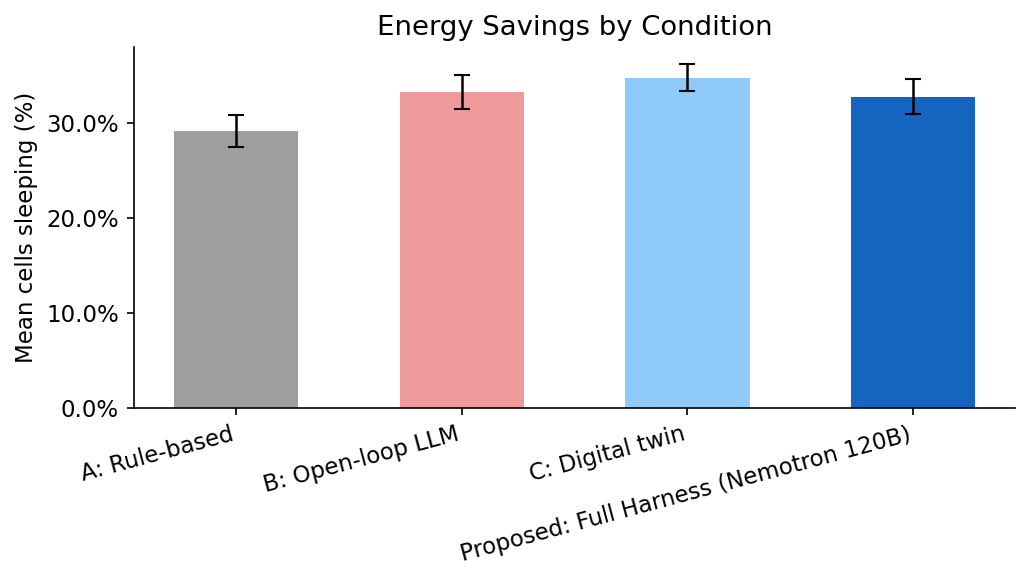

                                        condition     mean       se
                                   baseline_rules 0.291667 0.016489
                       baseline_openloop_vtzcycle 0.332341 0.018123
                   baseline_digital_twin_vtzcycle 0.347718 0.014207
full_harness_vtzcycle__nemotron-3-super-120b-a12b 0.327629 0.018401


In [5]:
# ── 2a. Mean sleeping fraction per condition ──────────────────────────────────
energy_stats = (
    df_main.groupby('condition')['sleep_fraction']
    .agg(['mean', 'std', 'count'])
    .reindex(CONDITION_ORDER)
    .reset_index()
)
energy_stats['se'] = energy_stats['std'] / np.sqrt(energy_stats['count'])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [CONDITION_LABELS[c] for c in energy_stats['condition']],
    energy_stats['mean'] * 100,
    yerr=energy_stats['se'] * 100,
    color=[PALETTE[c] for c in energy_stats['condition']],
    capsize=4, width=0.55, error_kw={'linewidth': 1.2},
)
ax.set_ylabel('Mean cells sleeping (%)')
ax.set_title('Energy Savings by Condition')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'analysis' / 'fig_energy_savings.pdf', bbox_inches='tight')
plt.show()
print(energy_stats[['condition','mean','se']].to_string(index=False))

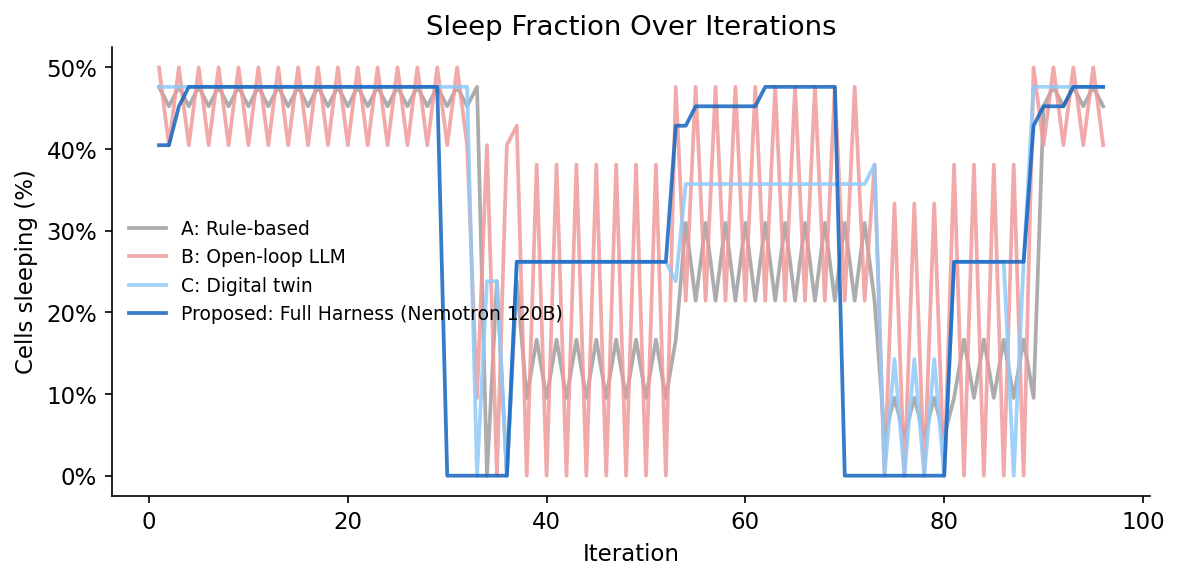

In [6]:
# ── 2b. Sleep fraction over iterations (line chart) ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for cond in CONDITION_ORDER:
    sub = df_main[df_main['condition'] == cond].sort_values('iteration')
    ax.plot(sub['iteration'], sub['sleep_fraction'] * 100,
            label=CONDITION_LABELS[cond], color=PALETTE[cond],
            linewidth=1.8, alpha=0.85)

ax.set_xlabel('Iteration')
ax.set_ylabel('Cells sleeping (%)')
ax.set_title('Sleep Fraction Over Iterations')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'analysis' / 'fig_sleep_over_time.pdf', bbox_inches='tight')
plt.show()

## 3. QoS preservation

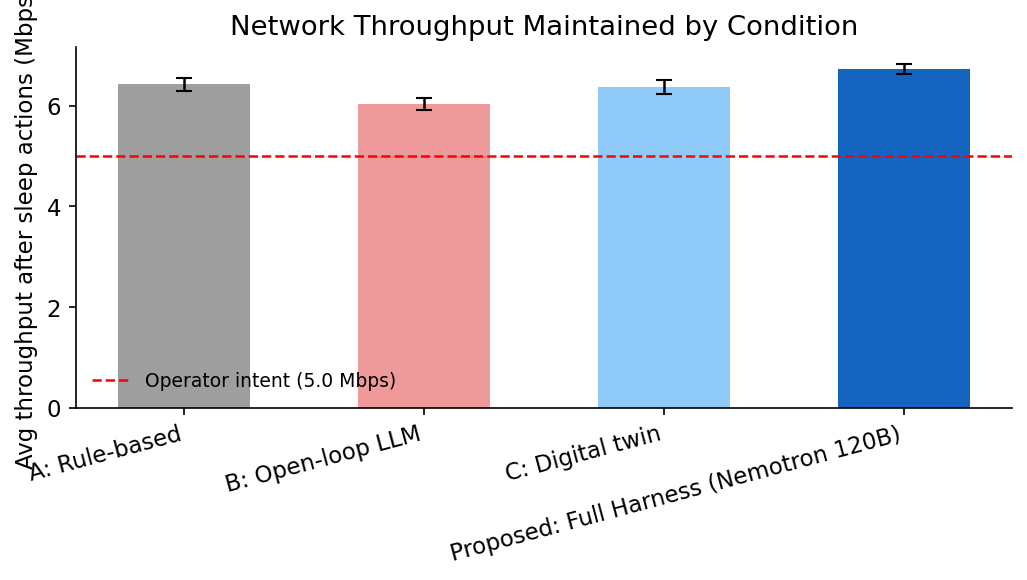

                                        condition  mean    se
                                   baseline_rules 6.423 0.136
                       baseline_openloop_vtzcycle 6.028 0.120
                   baseline_digital_twin_vtzcycle 6.372 0.136
full_harness_vtzcycle__nemotron-3-super-120b-a12b 6.728 0.097


In [7]:
# ── 3a. Average post-action throughput per condition ──────────────────────────
# The VIAVI scenario maintains aggregate throughput above the 5 Mbps operator
# intent even with aggressive sleep actions (network has sufficient capacity
# headroom). We therefore report the actual throughput maintained rather than
# a binary violation rate, which would be zero for all conditions.
tp_stats = (
    df_main.groupby('condition')['avg_throughput_mbps']
    .agg(['mean', 'std', 'count'])
    .reindex(CONDITION_ORDER)
    .reset_index()
)
tp_stats['se'] = tp_stats['std'] / np.sqrt(tp_stats['count'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    [CONDITION_LABELS[c] for c in tp_stats['condition']],
    tp_stats['mean'],
    yerr=tp_stats['se'],
    color=[PALETTE[c] for c in tp_stats['condition']],
    capsize=4, width=0.55, error_kw={'linewidth': 1.2},
)
ax.axhline(QOS_VIOLATION_THRESHOLD_MBPS, color='red', linestyle='--',
           linewidth=1.2, label=f'Operator intent ({QOS_VIOLATION_THRESHOLD_MBPS} Mbps)')
ax.set_ylabel('Avg throughput after sleep actions (Mbps)')
ax.set_title('Network Throughput Maintained by Condition')
ax.legend(fontsize=9, frameon=False)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'analysis' / 'fig_throughput.pdf', bbox_inches='tight')
plt.show()
print(tp_stats[['condition','mean','se']].round(3).to_string(index=False))

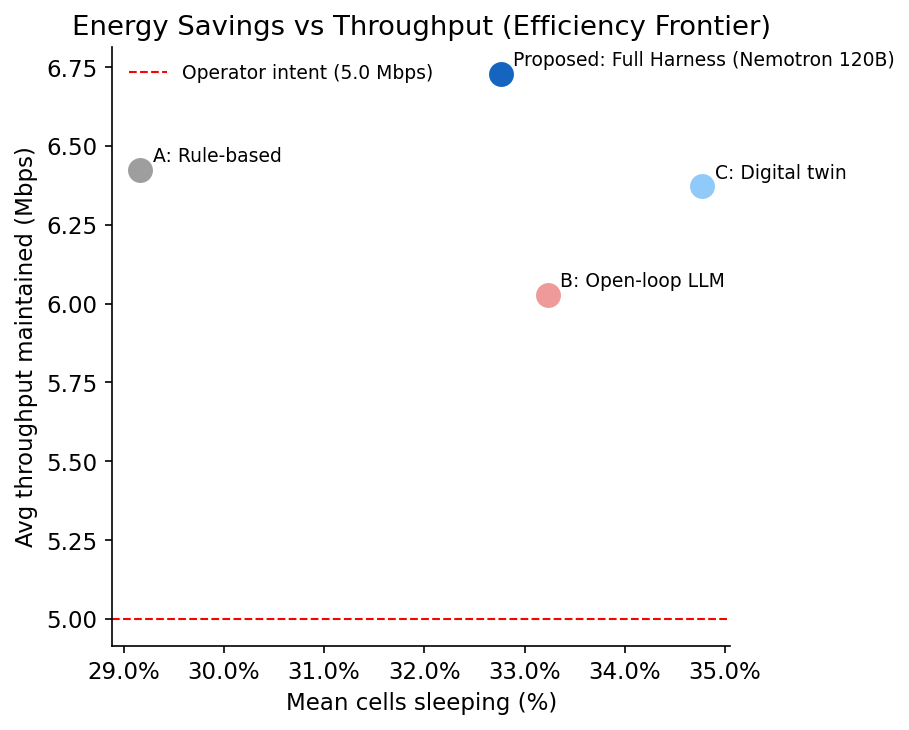

In [8]:
# ── 3b. Energy savings vs throughput scatter (efficiency frontier) ─────────────
fig, ax = plt.subplots(figsize=(6, 5))
for cond in CONDITION_ORDER:
    e = energy_stats.loc[energy_stats['condition'] == cond, 'mean'].values
    t = tp_stats.loc[tp_stats['condition'] == cond, 'mean'].values
    if len(e) == 0 or len(t) == 0 or np.isnan(e[0]) or np.isnan(t[0]):
        continue
    ax.scatter(e[0] * 100, t[0], color=PALETTE[cond], s=120, zorder=3)
    ax.annotate(
        CONDITION_LABELS[cond], (e[0] * 100, t[0]),
        textcoords='offset points', xytext=(6, 4), fontsize=9
    )

ax.axhline(QOS_VIOLATION_THRESHOLD_MBPS, color='red', linestyle='--',
           linewidth=1.0, label=f'Operator intent ({QOS_VIOLATION_THRESHOLD_MBPS} Mbps)')
ax.set_xlabel('Mean cells sleeping (%)')
ax.set_ylabel('Avg throughput maintained (Mbps)')
ax.set_title('Energy Savings vs Throughput (Efficiency Frontier)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'analysis' / 'fig_tradeoff.pdf', bbox_inches='tight')
plt.show()

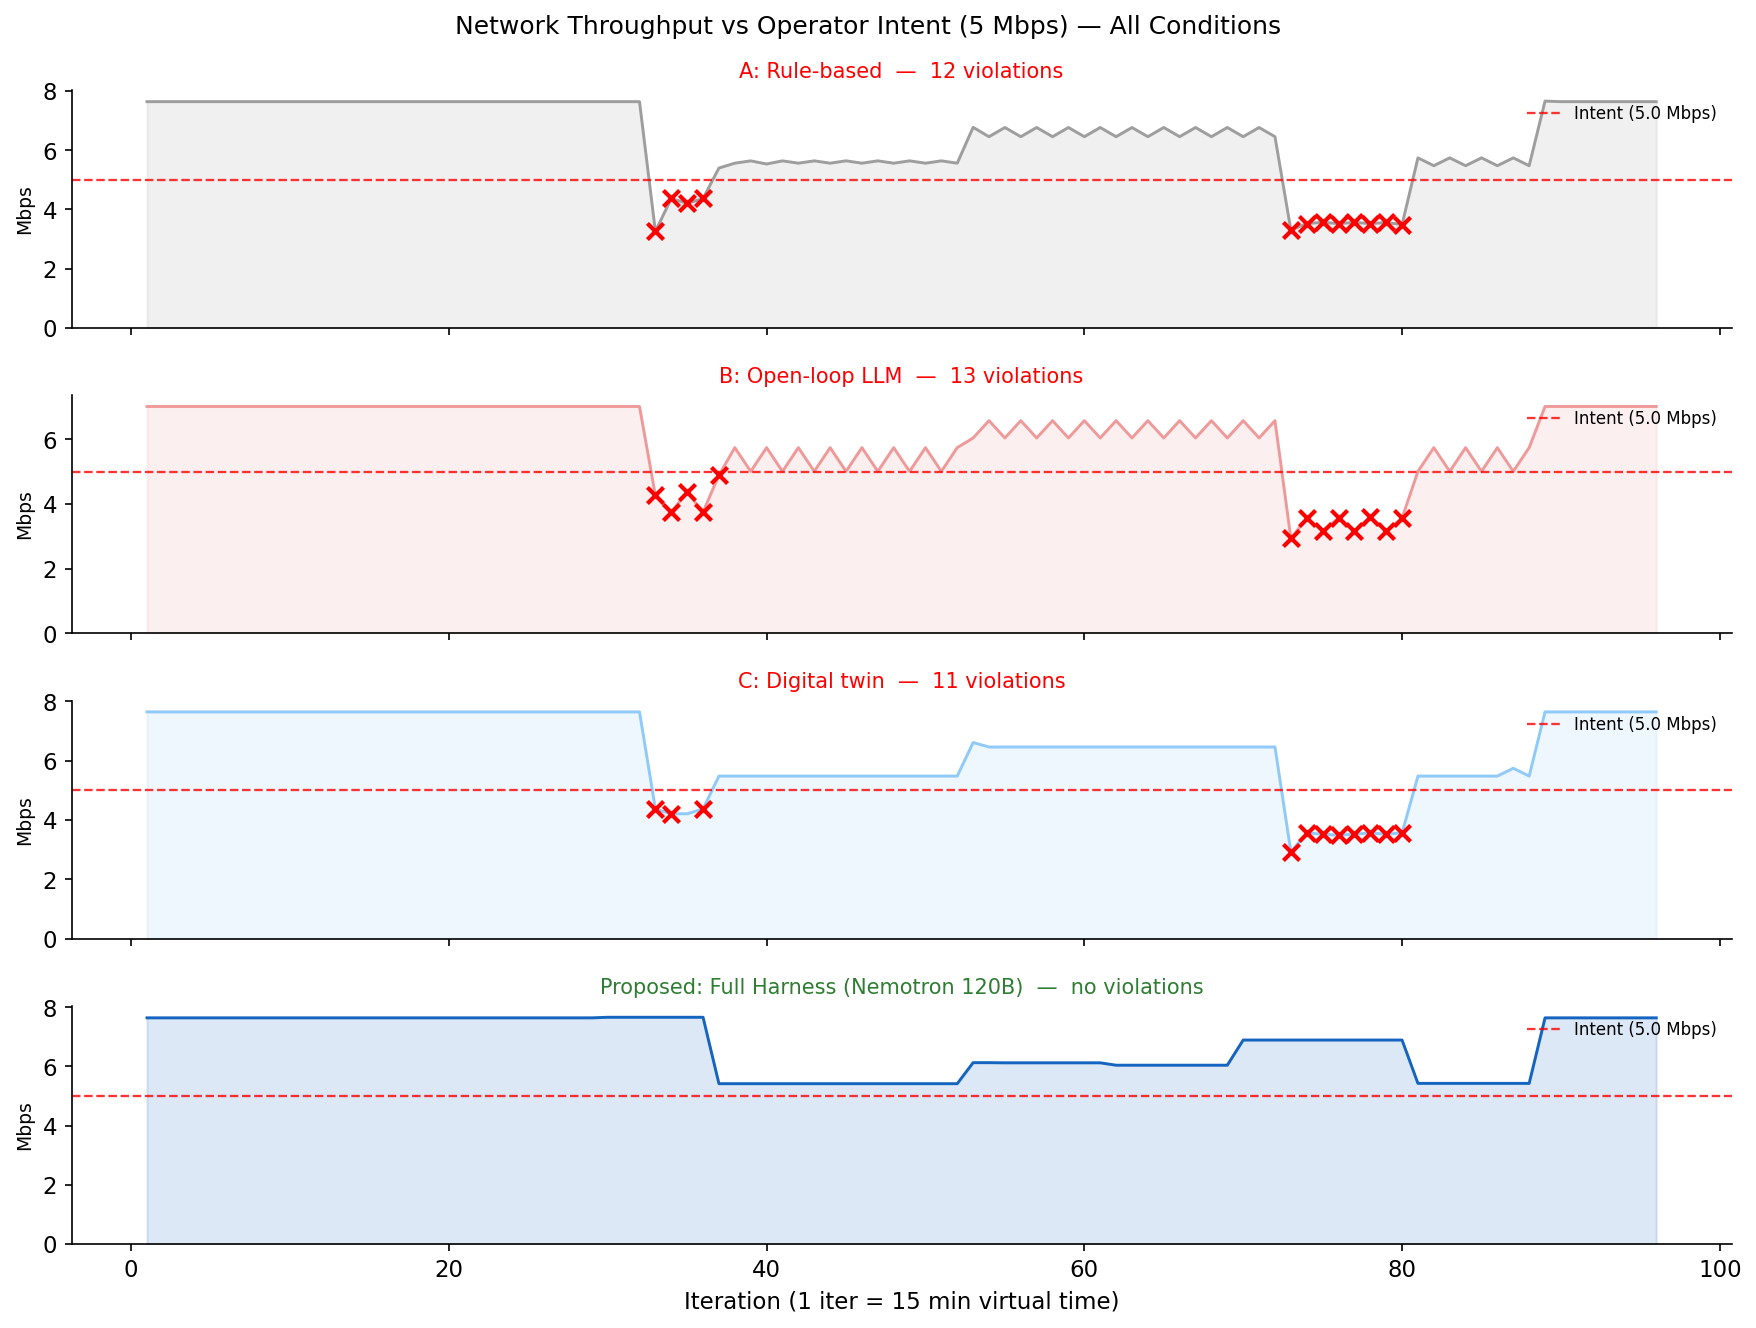

QoS violations per condition (at 5 Mbps intent):
condition
C: Digital twin                           11
B: Open-loop LLM                          13
A: Rule-based                             12
Proposed: Full Harness (Nemotron 120B)     0


In [9]:
# ── 3c. QoS violation timeline — throughput vs intent for all conditions ───────
# Each panel shows network throughput over 96 iterations.
# Red ✗ markers = QoS violation (throughput < 5 Mbps intent).
# This makes the "cost" of each baseline visible compared to the full harness.

fig, axes = plt.subplots(len(CONDITION_ORDER), 1, figsize=(12, 9), sharex=True)

for ax, cond in zip(axes, CONDITION_ORDER):
    sub   = df_main[df_main['condition'] == cond].sort_values('iteration')
    iters = sub['iteration'].values
    tp    = sub['avg_throughput_mbps'].values
    viols = sub[sub['qos_violated'] == 1]
    n_v   = int(sub['qos_violated'].sum())

    ax.fill_between(iters, tp, alpha=0.15, color=PALETTE[cond])
    ax.plot(iters, tp, color=PALETTE[cond], linewidth=1.4)
    ax.axhline(QOS_VIOLATION_THRESHOLD_MBPS, color='red', linestyle='--',
               linewidth=1.1, alpha=0.8, label=f'Intent ({QOS_VIOLATION_THRESHOLD_MBPS} Mbps)')

    if not viols.empty:
        ax.scatter(viols['iteration'], viols['avg_throughput_mbps'],
                   color='red', s=60, zorder=5, marker='x', linewidths=2)

    ax.set_ylabel('Mbps', fontsize=9)
    ax.set_ylim(bottom=0)
    viol_label = f'{n_v} violation{"s" if n_v != 1 else ""}' if n_v > 0 else 'no violations'
    ax.set_title(f'{CONDITION_LABELS[cond]}  —  {viol_label}', fontsize=10,
                 color='red' if n_v > 0 else '#2e7d32')
    ax.legend(fontsize=8, frameon=False, loc='upper right')

axes[-1].set_xlabel('Iteration (1 iter = 15 min virtual time)')
fig.suptitle('Network Throughput vs Operator Intent (5 Mbps) — All Conditions', fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'analysis' / 'fig_qos_violations.pdf', bbox_inches='tight')
plt.show()

# Summary table
print('QoS violations per condition (at 5 Mbps intent):')
print(df_main.groupby('condition')['qos_violated'].sum()
      .rename(index=CONDITION_LABELS).rename('violations').to_string())

## 4. Decision quality

Decision quality (LLM conditions with validator):
                                                   approval_mean  \
condition                                                          
baseline_digital_twin_vtzcycle                              0.95   
full_harness_vtzcycle__nemotron-3-super-120b-a12b           1.00   

                                                   approval_std  avg_proposed  \
condition                                                                       
baseline_digital_twin_vtzcycle                            0.224         9.700   
full_harness_vtzcycle__nemotron-3-super-120b-a12b         0.000         7.692   

                                                   avg_rejected  
condition                                                        
baseline_digital_twin_vtzcycle                              0.5  
full_harness_vtzcycle__nemotron-3-super-120b-a12b           0.0  


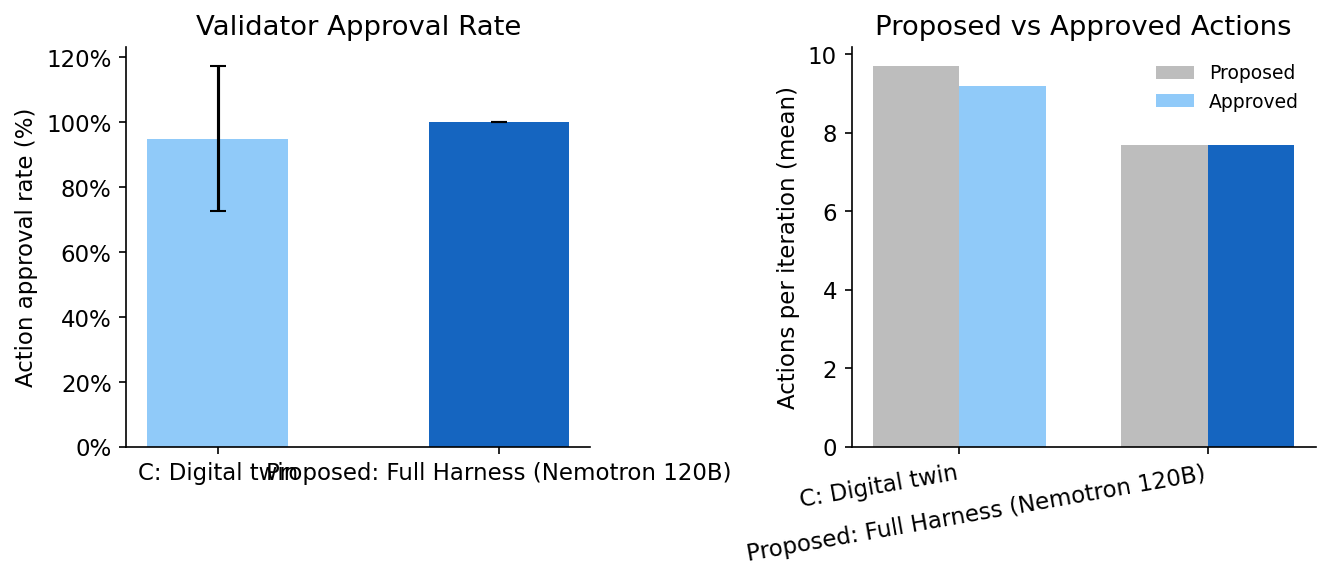

In [10]:
# ── Approval rate (only meaningful for LLM conditions with a validator) ───────
_all_llm_conds = ['baseline_digital_twin_vtzcycle', 'full_harness_vtzcycle__nemotron-3-super-120b-a12b']
dec_stats = (
    df_main[df_main['condition'].isin(_all_llm_conds) & df_main['n_proposed'].gt(0)]
    .groupby('condition')[['approval_rate', 'n_proposed', 'n_rejected']]
    .agg({'approval_rate': ['mean', 'std'], 'n_proposed': 'mean', 'n_rejected': 'mean'})
)
dec_stats.columns = ['approval_mean', 'approval_std', 'avg_proposed', 'avg_rejected']
llm_conds = [c for c in _all_llm_conds if c in dec_stats.index]
print('Decision quality (LLM conditions with validator):')
print(dec_stats.round(3))

if not llm_conds:
    print('⚠  No validator conditions in data yet — skipping decision quality chart.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].bar(
        [CONDITION_LABELS[c] for c in llm_conds],
        dec_stats.loc[llm_conds, 'approval_mean'] * 100,
        yerr=dec_stats.loc[llm_conds, 'approval_std'] * 100,
        color=[PALETTE[c] for c in llm_conds], capsize=4, width=0.5
    )
    axes[0].set_ylabel('Action approval rate (%)')
    axes[0].set_title('Validator Approval Rate')
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

    x = np.arange(len(llm_conds))
    w = 0.35
    axes[1].bar(x - w/2, dec_stats.loc[llm_conds, 'avg_proposed'],
                width=w, color='#bdbdbd', label='Proposed')
    axes[1].bar(x + w/2,
                dec_stats.loc[llm_conds, 'avg_proposed'] - dec_stats.loc[llm_conds, 'avg_rejected'],
                width=w, color=[PALETTE[c] for c in llm_conds], label='Approved')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([CONDITION_LABELS[c] for c in llm_conds], rotation=10, ha='right')
    axes[1].set_ylabel('Actions per iteration (mean)')
    axes[1].set_title('Proposed vs Approved Actions')
    axes[1].legend(fontsize=9, frameon=False)

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'analysis' / 'fig_decision_quality.pdf', bbox_inches='tight')
    plt.show()

## 5. Ablation study

In [11]:
# ── Ablation: each tool added to digital-twin baseline ───────────────────────
ABLATION_TOOL_MAP = {
    f'ablation_{t}': t for t in TOOL_NAMES
}

df_abl  = df[df['condition'].isin(list(ABLATION_TOOL_MAP.keys()) + ['baseline_digital_twin_vtzcycle', 'full_harness_vtzcycle'])].copy()
abl_agg = df_abl.groupby('condition')[['sleep_fraction', 'qos_violated']].mean().round(4)

abl_rows = []
if 'baseline_digital_twin_vtzcycle' in abl_agg.index:
    base_energy = abl_agg.loc['baseline_digital_twin_vtzcycle', 'sleep_fraction']
    base_qos    = abl_agg.loc['baseline_digital_twin_vtzcycle', 'qos_violated']

    for cond_key, tool_name in ABLATION_TOOL_MAP.items():
        if cond_key not in abl_agg.index:
            continue
        row = abl_agg.loc[cond_key]
        abl_rows.append({
            'tool':               tool_name,
            'sleep_fraction':     row['sleep_fraction'],
            'delta_energy_pct':   (row['sleep_fraction'] - base_energy) * 100,
            'qos_violation_rate': row['qos_violated'],
            'delta_qos_pct':      (row['qos_violated']   - base_qos)   * 100,
        })

if not abl_rows:
    print('⚠  No ablation runs found — skipping ablation chart.')
    print('   Run full_harness_vtzcycle.py with individual --tools flags to generate ablation data.')
    print('   Example: python experiments/full_harness_vtzcycle.py --tools historical_kpi --iterations 96')
else:
    df_ablation = pd.DataFrame(abl_rows).set_index('tool')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    colors_energy = ['#1565c0' if d >= 0 else '#ef5350' for d in df_ablation['delta_energy_pct']]
    axes[0].barh(df_ablation.index, df_ablation['delta_energy_pct'], color=colors_energy)
    axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_xlabel('Δ Energy savings vs Baseline C (pp)')
    axes[0].set_title('Marginal Energy Gain per Tool')

    colors_qos = ['#1565c0' if d <= 0 else '#ef5350' for d in df_ablation['delta_qos_pct']]
    axes[1].barh(df_ablation.index, df_ablation['delta_qos_pct'], color=colors_qos)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_xlabel('Δ QoS violation rate vs Baseline C (pp)')
    axes[1].set_title('Marginal QoS Impact per Tool (negative = better)')

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'analysis' / 'fig_ablation.pdf', bbox_inches='tight')
    plt.show()
    print(df_ablation.round(4))

⚠  No ablation runs found — skipping ablation chart.
   Run full_harness_vtzcycle.py with individual --tools flags to generate ablation data.
   Example: python experiments/full_harness_vtzcycle.py --tools historical_kpi --iterations 96


## 6. Tool Decision Trace (Full Harness)

For each iteration the harness saves `tool_blocks`: which cells were blocked by which tool
and which cells ended up as sleep/wake candidates. These charts make the reasoning behind
every decision visible rather than hidden inside log messages.

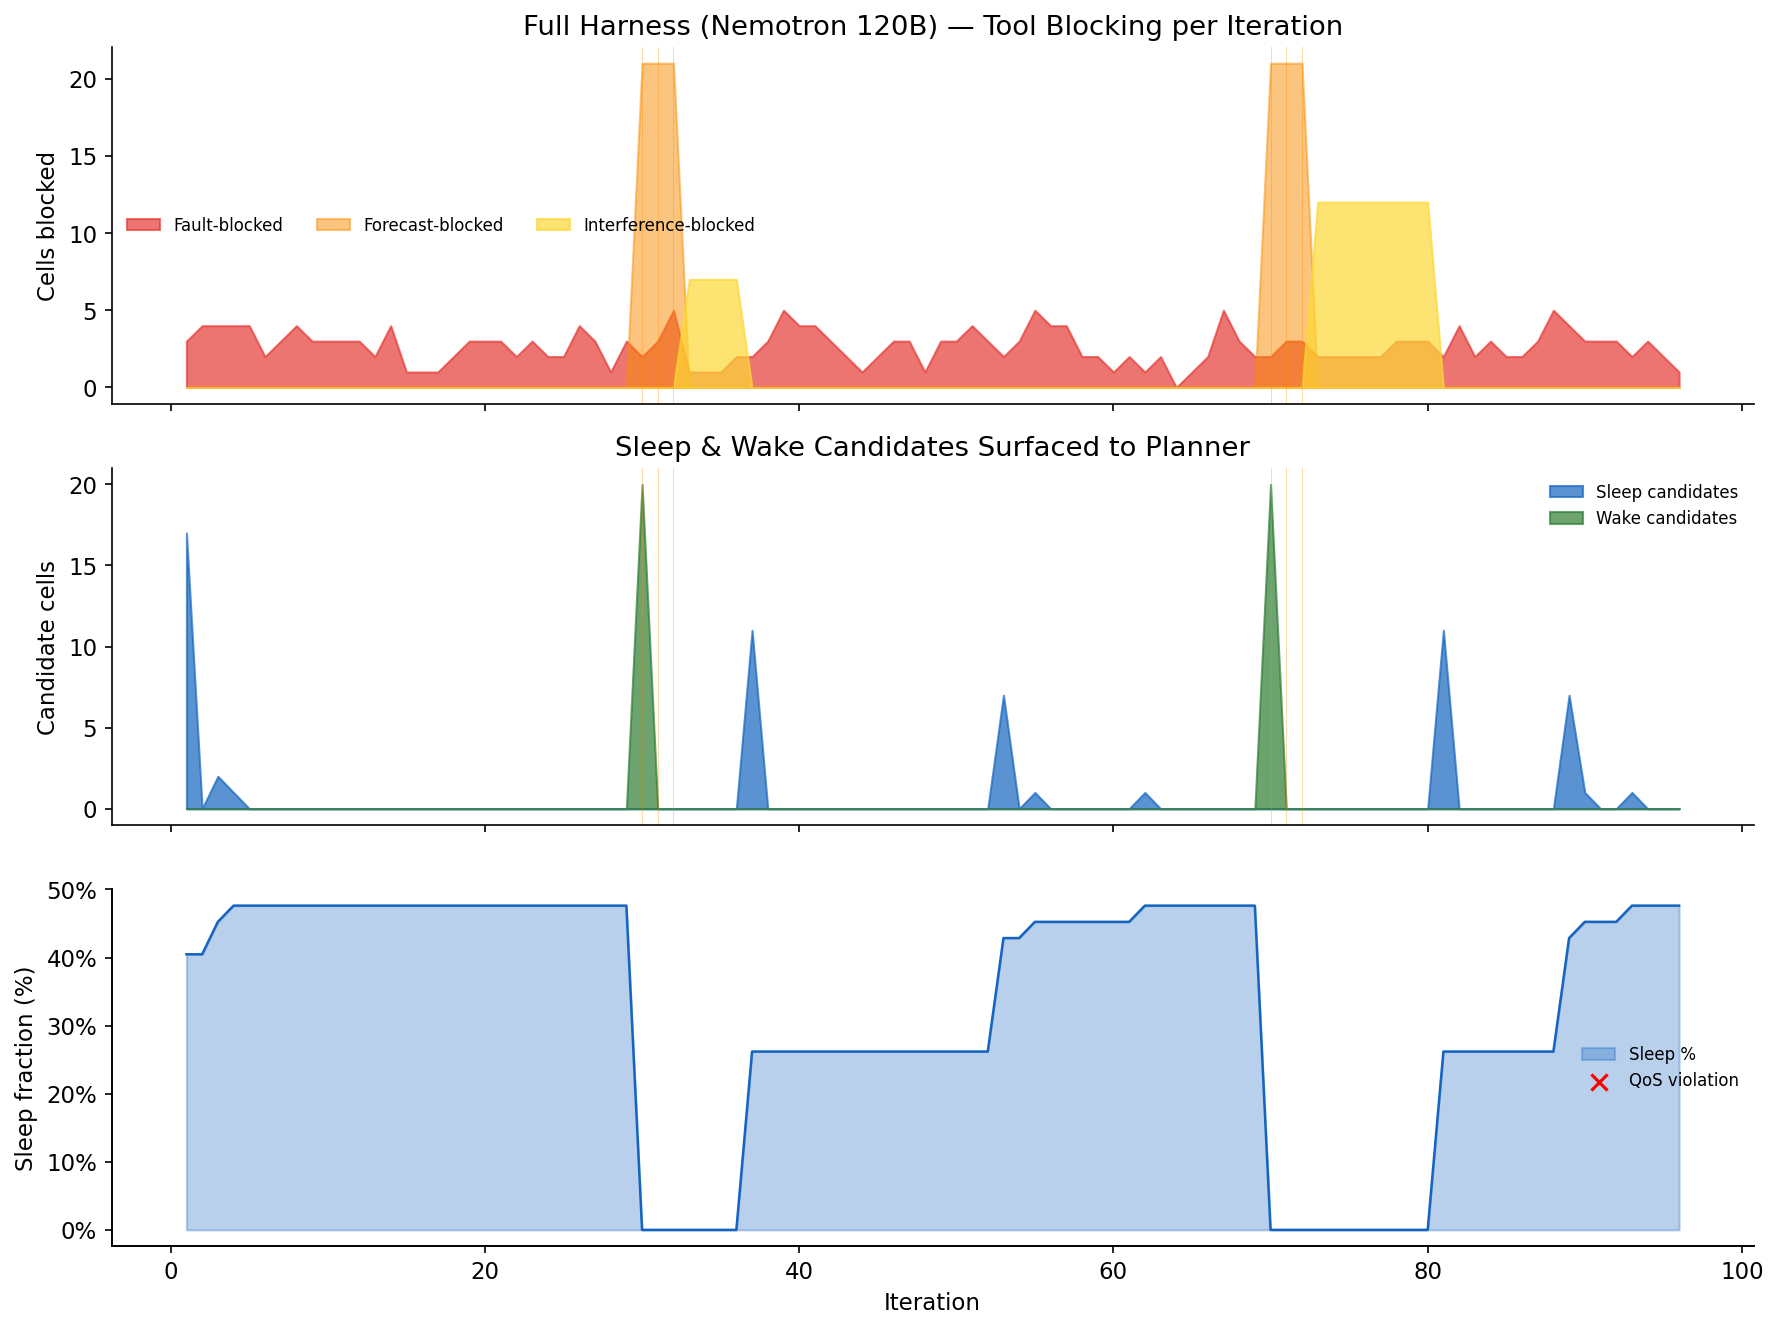

Surge-imminent iterations: [np.int64(30), np.int64(31), np.int64(32), np.int64(70), np.int64(71), np.int64(72)]


In [12]:
# ── 6a. Per-iteration tool blocking timeline ──────────────────────────────────
df_fh = df[df['condition'] == 'full_harness_vtzcycle__nemotron-3-super-120b-a12b'].copy().sort_values('iteration')

has_blocks = (
    'tool_blocks' in df_fh.columns
    and df_fh['tool_blocks'].apply(lambda x: isinstance(x, dict) and bool(x)).any()
)

if not has_blocks:
    print('tool_blocks not in results — re-run full_harness_vtzcycle after the context.py update.')
else:
    def _tb(row, key):
        tb = row.get('tool_blocks', {})
        if not isinstance(tb, dict):
            return 0
        val = tb.get(key, [])
        return len(val) if isinstance(val, list) else int(bool(val))

    df_fh['n_fault_blocked']        = df_fh.apply(lambda r: _tb(r, 'fault_blocked'),        axis=1)
    df_fh['n_forecast_blocked']     = df_fh.apply(lambda r: _tb(r, 'forecast_blocked'),     axis=1)
    df_fh['n_interference_blocked'] = df_fh.apply(lambda r: _tb(r, 'interference_blocked'), axis=1)
    df_fh['n_sleep_candidates']     = df_fh.apply(lambda r: _tb(r, 'sleep_candidates'),     axis=1)
    df_fh['n_wake_candidates']      = df_fh.apply(lambda r: _tb(r, 'wake_candidates'),      axis=1)
    df_fh['surge_imminent']         = df_fh['tool_blocks'].apply(
        lambda x: int(x.get('surge_imminent', False)) if isinstance(x, dict) else 0
    )

    iters = df_fh['iteration'].values

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    # — Panel 1: blocking counts per tool ————————————————————————————————————
    ax = axes[0]
    ax.fill_between(iters, df_fh['n_fault_blocked'],        alpha=0.7, label='Fault-blocked',        color='#e53935')
    ax.fill_between(iters, df_fh['n_forecast_blocked'],     alpha=0.5, label='Forecast-blocked',     color='#fb8c00')
    ax.fill_between(iters, df_fh['n_interference_blocked'], alpha=0.7, label='Interference-blocked', color='#fdd835')
    for xs in iters[df_fh['surge_imminent'].values.astype(bool)]:
        ax.axvline(xs, color='#fb8c00', linewidth=0.4, alpha=0.4)
    ax.set_ylabel('Cells blocked')
    ax.set_title('Full Harness (Nemotron 120B) — Tool Blocking per Iteration')
    ax.legend(fontsize=8, frameon=False, ncol=3)

    # — Panel 2: sleep / wake candidates ————————————————————————————————————
    ax = axes[1]
    ax.fill_between(iters, df_fh['n_sleep_candidates'], alpha=0.7, label='Sleep candidates', color='#1565c0')
    ax.fill_between(iters, df_fh['n_wake_candidates'],  alpha=0.7, label='Wake candidates',  color='#2e7d32')
    for xs in iters[df_fh['surge_imminent'].values.astype(bool)]:
        ax.axvline(xs, color='#fb8c00', linewidth=0.4, alpha=0.4)
    ax.set_ylabel('Candidate cells')
    ax.set_title('Sleep & Wake Candidates Surfaced to Planner')
    ax.legend(fontsize=8, frameon=False)

    # — Panel 3: QoS violations alongside sleep fraction ————————————————————
    ax = axes[2]
    ax2 = ax.twinx()
    ax.fill_between(iters, df_fh['sleep_fraction'] * 100, alpha=0.3, color='#1565c0', label='Sleep %')
    ax.plot(iters,          df_fh['sleep_fraction'] * 100, color='#1565c0', linewidth=1.2)
    viol_iters = iters[df_fh['qos_violated'].values.astype(bool)]
    ax2.scatter(viol_iters, [1] * len(viol_iters), marker='x', color='red', s=60, zorder=4, label='QoS violation')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Sleep fraction (%)')
    ax2.set_yticks([])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, frameon=False)

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'analysis' / 'fig_tool_trace.pdf', bbox_inches='tight')
    plt.show()
    print(f'Surge-imminent iterations: {list(iters[df_fh["surge_imminent"].values.astype(bool)])}')

In [13]:
# ── 6b. Decision trace table around surge transitions ────────────────────────
# Shows the 3 iterations before and after each surge so you can see exactly
# which tool triggered a proactive wake vs which iterations had reactive lag.
if has_blocks:
    SURGE_CENTERS = [33, 73]   # Night→Early (iter 33) and Afternoon→Evening_1 (iter 73)
    WINDOW        = 3

    rows_out = []
    for center in SURGE_CENTERS:
        lo, hi = max(1, center - WINDOW), min(df_fh['iteration'].max(), center + WINDOW)
        for _, row in df_fh[(df_fh['iteration'] >= lo) & (df_fh['iteration'] <= hi)].iterrows():
            tb    = row.get('tool_blocks', {}) or {}
            rows_out.append({
                'iter':          int(row['iteration']),
                'surge_imminent': '⚠' if tb.get('surge_imminent') else '',
                'forecast_blk':  tb.get('forecast_blocked', []),
                'fault_blk':     tb.get('fault_blocked', []),
                'interf_blk':    tb.get('interference_blocked', []),
                'sleep_cands':   tb.get('sleep_candidates', []),
                'wake_cands':    tb.get('wake_candidates', []),
                'n_approved':    int(row.get('n_approved', 0)),
                'tp_mbps':       round(row.get('avg_throughput_mbps', 0) or 0, 2),
                'qos_ok':        '✓' if not row.get('qos_violated') else '✗ VIOL',
            })

    df_trace = pd.DataFrame(rows_out)
    pd.set_option('display.max_colwidth', 40)
    print('Decision trace at surge transitions (iterations ±3 around iters 33 and 73):')
    print()
    print(df_trace.to_string(index=False))

Decision trace at surge transitions (iterations ±3 around iters 33 and 73):

 iter surge_imminent                                                               forecast_blk         fault_blk                                 interf_blk sleep_cands                                                             wake_cands  n_approved  tp_mbps qos_ok
   30              ⚠ [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]           [3, 12]                                         []          [] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20]          20     7.66      ✓
   31              ⚠ [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]       [3, 11, 12]                                         []          []                                                                     []           0     7.66      ✓
   32              ⚠ [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] [2, 3, 8, 11, 12]      

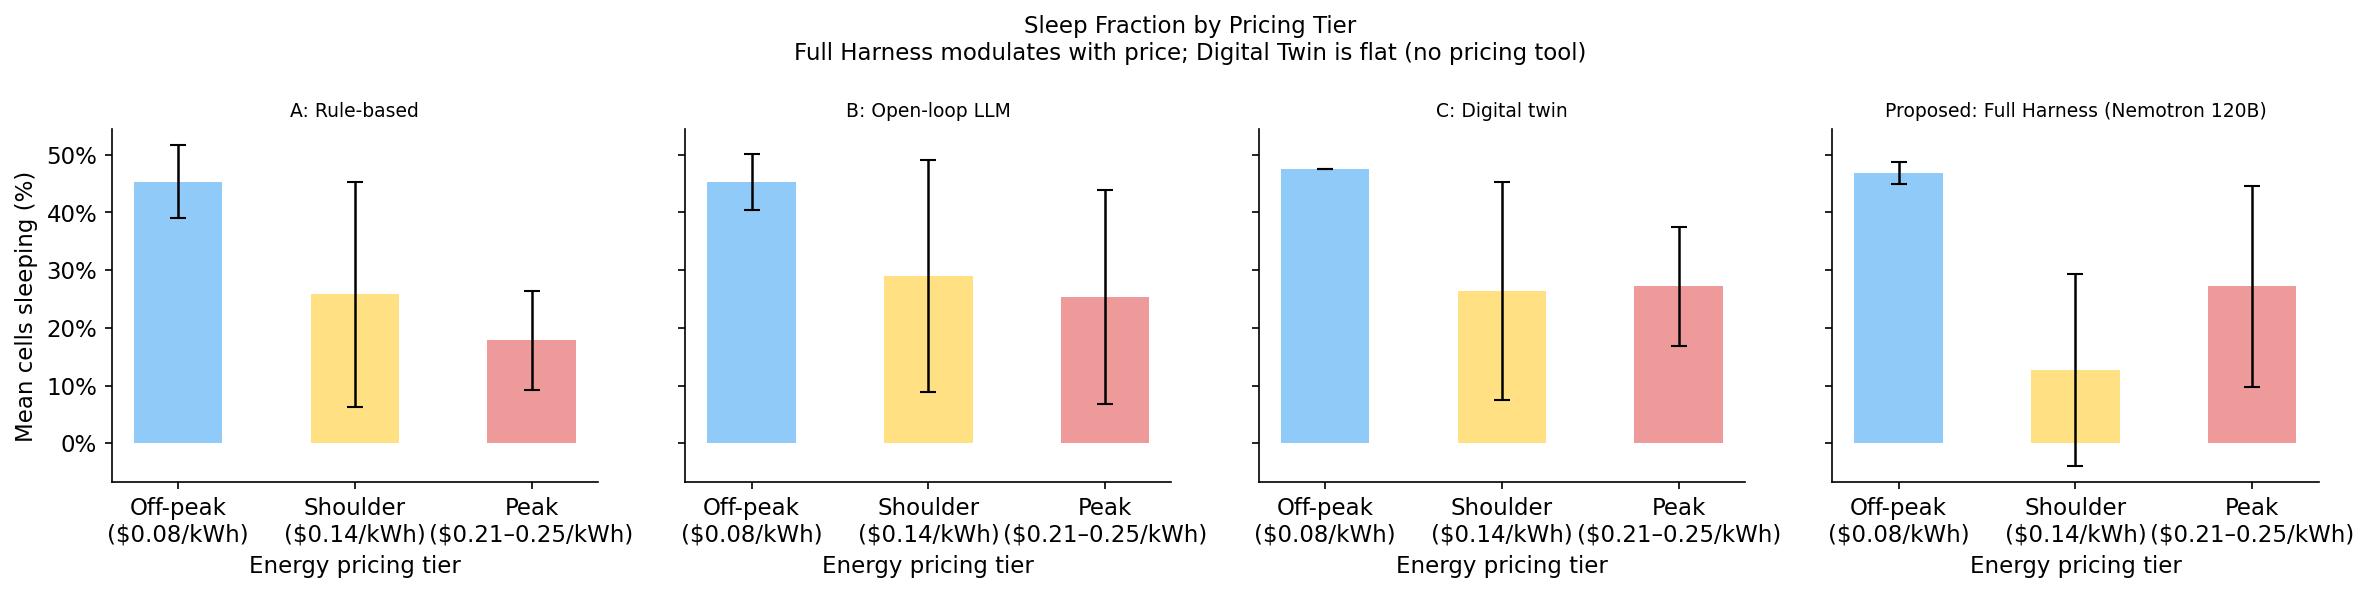

Mean sleep % by pricing tier:
pricing_tier                            off_peak  shoulder  peak
C: Digital twin                             47.6      26.4  27.2
B: Open-loop LLM                            45.2      29.0  25.3
A: Rule-based                               45.4      25.8  17.9
Proposed: Full Harness (Nemotron 120B)      46.8      12.7  27.2


In [14]:
# ── 6c. Pricing-aware sleep behaviour: all conditions by pricing tier ──────────
# All runs share the same VTZ clock, so every iteration maps to the same pricing
# tier regardless of condition.  We extract the tier-per-iteration from the
# Nemotron run (which logged it) and join it onto all conditions.
# Digital twin has no pricing tool — its sleep fraction should be flat across
# tiers, making the full harness's pricing-aware modulation clearly visible.

TIER_ORDER  = ["off_peak", "shoulder", "peak"]
TIER_COLORS = {"off_peak": "#90caf9", "shoulder": "#ffe082", "peak": "#ef9a9a"}
TIER_LABELS = {"off_peak": "Off-peak\n($0.08/kWh)", "shoulder": "Shoulder\n($0.14/kWh)", "peak": "Peak\n($0.21–0.25/kWh)"}

# Build iter → pricing_tier map from the Nemotron run
def _get_tier(row):
    if "pricing_tier" in row and row["pricing_tier"]:
        return row["pricing_tier"]
    tb = row.get("tool_blocks", {})
    if isinstance(tb, dict):
        return tb.get("pricing_tier", "")
    return ""

nemotron_tiers = (
    df[df["condition"] == "full_harness_vtzcycle__nemotron-3-super-120b-a12b"]
    .assign(pricing_tier=lambda d: d.apply(_get_tier, axis=1))
    [["iteration", "pricing_tier"]]
    .query("pricing_tier != ''")
    .drop_duplicates("iteration")
    .set_index("iteration")["pricing_tier"]
)

if nemotron_tiers.empty:
    print("pricing_tier not found in Nemotron results — cannot derive tier map.")
else:
    # Apply the tier map to all main conditions
    df_pricing = df_main.copy()
    df_pricing["pricing_tier"] = df_pricing["iteration"].map(nemotron_tiers)
    df_pricing = df_pricing[df_pricing["pricing_tier"].isin(TIER_ORDER)]

    plot_conds = [c for c in CONDITION_ORDER if c in df_pricing["condition"].unique()]
    n = len(plot_conds)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, cond in zip(axes, plot_conds):
        sub   = df_pricing[df_pricing["condition"] == cond]
        means = sub.groupby("pricing_tier")["sleep_fraction"].mean().reindex(TIER_ORDER) * 100
        errs  = sub.groupby("pricing_tier")["sleep_fraction"].std().reindex(TIER_ORDER) * 100

        ax.bar([TIER_LABELS[t] for t in TIER_ORDER], means, yerr=errs,
               color=[TIER_COLORS[t] for t in TIER_ORDER],
               capsize=4, width=0.5, error_kw={"linewidth": 1.2})
        ax.set_title(CONDITION_LABELS.get(cond, cond), fontsize=9)
        ax.set_ylabel("Mean cells sleeping (%)" if ax is axes[0] else "")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xlabel("Energy pricing tier")

    fig.suptitle(
        "Sleep Fraction by Pricing Tier\n"
        "Full Harness modulates with price; Digital Twin is flat (no pricing tool)",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "analysis" / "fig_pricing_sleep.pdf", bbox_inches="tight")
    plt.show()

    pivot = (
        df_pricing.groupby(["condition", "pricing_tier"])["sleep_fraction"]
        .mean().mul(100).round(1).unstack("pricing_tier").reindex(columns=TIER_ORDER)
    )
    pivot.index = [CONDITION_LABELS.get(c, c) for c in pivot.index]
    print("Mean sleep % by pricing tier:")
    print(pivot.to_string())

In [15]:
# ── 6d. Planner pricing adherence — did the LLM act on the pricing signal? ────
# Inspects the 'reason' text in proposed_actions for full_harness iterations
# where pricing_tier == 'peak'.  If the planner is following STEP 2.5 it will
# write reasons containing "peak pricing".  Reports adherence rate so you can
# benchmark Qwen 7B vs Nemotron without manually reading the JSONL.

df_fh_p = df[df["condition"] == "full_harness_vtzcycle__nemotron-3-super-120b-a12b"].copy()

has_pricing2 = (
    "pricing_tier" in df_fh_p.columns
    and df_fh_p["pricing_tier"].ne("").any()
)

if not has_pricing2:
    # fallback: try extracting from tool_blocks
    def _get_tier2(row):
        tb = row.get("tool_blocks", {})
        if isinstance(tb, dict):
            return tb.get("pricing_tier", "")
        return ""
    df_fh_p["pricing_tier"] = df_fh_p.apply(_get_tier2, axis=1)
    has_pricing2 = df_fh_p["pricing_tier"].ne("").any()

if not has_pricing2:
    print("pricing_tier not in results — re-run full_harness after latest code pull.")
else:
    peak_iters = df_fh_p[df_fh_p["pricing_tier"] == "peak"]
    total_peak  = len(peak_iters)

    # Count sleep actions where reason mentions pricing
    pricing_keywords = ["peak pricing", "peak price", "cost saving", "pricing"]

    def _pricing_reason(actions):
        if not isinstance(actions, list):
            return 0, 0
        sleeps = [a for a in actions if isinstance(a, dict) and a.get("action") == "sleep"]
        priced = [a for a in sleeps
                  if any(kw in str(a.get("reason", "")).lower() for kw in pricing_keywords)]
        return len(priced), len(sleeps)

    peak_iters = peak_iters.copy()
    peak_iters[["n_pricing_reasons", "n_sleep_actions"]] = peak_iters["proposed_actions"].apply(
        lambda x: pd.Series(_pricing_reason(x))
    )

    total_sleeps  = peak_iters["n_sleep_actions"].sum()
    priced_sleeps = peak_iters["n_pricing_reasons"].sum()
    iters_with_any_pricing = (peak_iters["n_pricing_reasons"] > 0).sum()

    adherence_pct = 100 * priced_sleeps / total_sleeps if total_sleeps > 0 else 0
    iter_pct      = 100 * iters_with_any_pricing / total_peak if total_peak > 0 else 0

    print("=== Planner Pricing Adherence (full_harness, peak-pricing iterations) ===")
    print(f"  Peak-pricing iterations : {total_peak}")
    print(f"  Sleep actions proposed  : {int(total_sleeps)}")
    print(f"  Actions citing pricing  : {int(priced_sleeps)}  ({adherence_pct:.0f}% of sleep actions)")
    print(f"  Iterations with ≥1 pricing reason: {iters_with_any_pricing} / {total_peak}  ({iter_pct:.0f}%)")
    print()
    if adherence_pct >= 70:
        print("✓  Planner is reliably following the peak-pricing instruction.")
    elif adherence_pct >= 30:
        print("⚠  Planner is inconsistently following the peak-pricing instruction.")
        print("   Consider switching to a larger model (e.g. Nemotron 120B).")
    else:
        print("✗  Planner is NOT following the peak-pricing instruction.")
        print("   Qwen 7B is likely ignoring STEP 2.5 — switch to Nemotron 120B/A12B.")

=== Planner Pricing Adherence (full_harness, peak-pricing iterations) ===
  Peak-pricing iterations : 48
  Sleep actions proposed  : 31
  Actions citing pricing  : 0  (0% of sleep actions)
  Iterations with ≥1 pricing reason: 0 / 48  (0%)

✗  Planner is NOT following the peak-pricing instruction.
   Qwen 7B is likely ignoring STEP 2.5 — switch to Nemotron 120B/A12B.


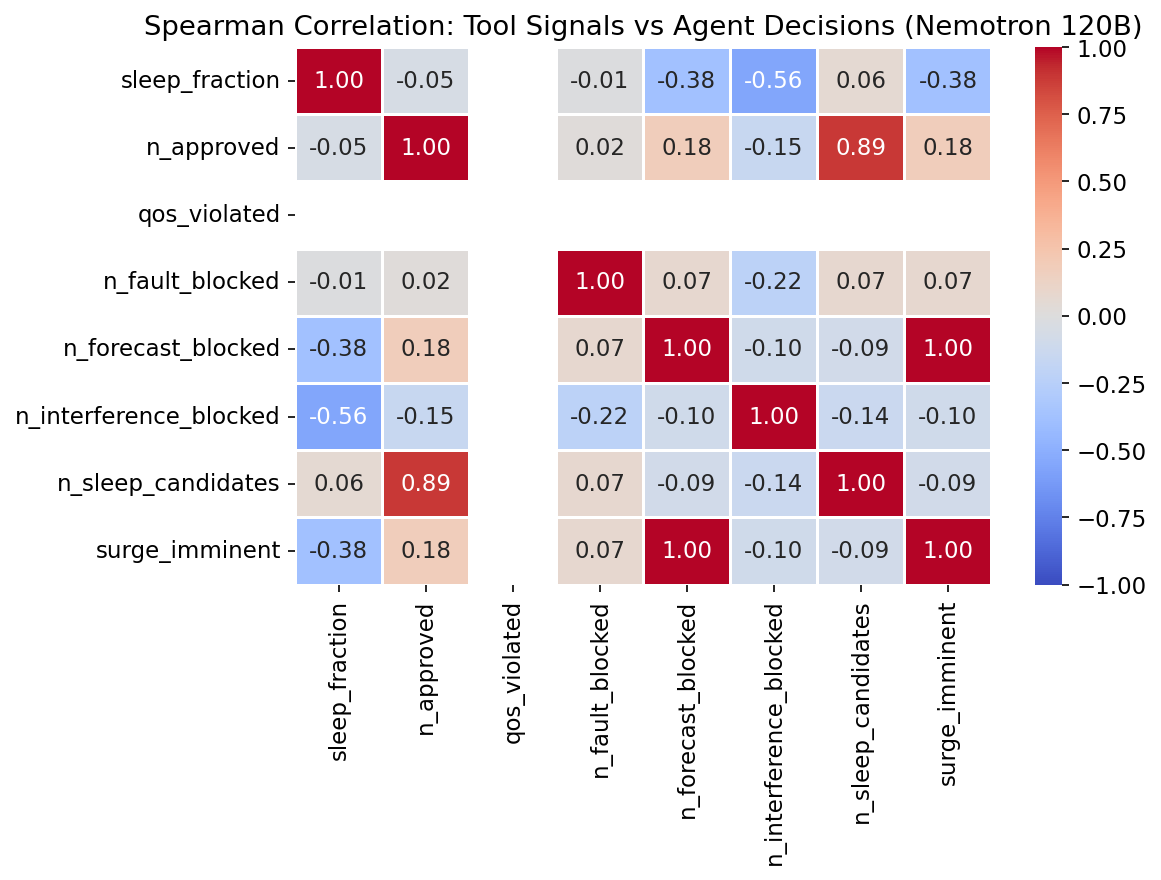

In [16]:
# ── 6c. Tool signal correlation with agent decisions ─────────────────────────
# Uses tool_blocks (now saved to JSONL) rather than tool_context (was never serialised).
df_fh2 = df[df['condition'] == 'full_harness_vtzcycle__nemotron-3-super-120b-a12b'].copy()

has_blocks2 = (
    'tool_blocks' in df_fh2.columns
    and df_fh2['tool_blocks'].apply(lambda x: isinstance(x, dict) and bool(x)).any()
)

if not has_blocks2:
    print('tool_blocks not in results — re-run full_harness_vtzcycle after the context.py update.')
else:
    def _corr_signals(row):
        tb = row.get('tool_blocks', {}) or {}
        return pd.Series({
            'n_fault_blocked':        len(tb.get('fault_blocked', [])        or []),
            'n_forecast_blocked':     len(tb.get('forecast_blocked', [])     or []),
            'n_interference_blocked': len(tb.get('interference_blocked', []) or []),
            'n_sleep_candidates':     len(tb.get('sleep_candidates', [])     or []),
            'surge_imminent':         int(tb.get('surge_imminent', False)),
        })

    signals2 = df_fh2.apply(_corr_signals, axis=1)
    df_corr2 = pd.concat(
        [df_fh2[['sleep_fraction', 'n_approved', 'qos_violated']].reset_index(drop=True),
         signals2.reset_index(drop=True)],
        axis=1
    ).dropna()

    corr_matrix = df_corr2.corr(method='spearman')
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
        center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5
    )
    ax.set_title('Spearman Correlation: Tool Signals vs Agent Decisions (Nemotron 120B)')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'analysis' / 'fig_tool_correlation.pdf', bbox_inches='tight')
    plt.show()

## 7. Statistical significance

In [17]:
# ── Mann-Whitney U: full harness vs each baseline ────────────────────────────
fh_energy = df_main[df_main['condition'] == 'full_harness_vtzcycle__nemotron-3-super-120b-a12b']['sleep_fraction'].values
fh_qos    = df_main[df_main['condition'] == 'full_harness_vtzcycle__nemotron-3-super-120b-a12b']['qos_violated'].values

sig_rows = []
for cond in ['baseline_rules', 'baseline_openloop_vtzcycle', 'baseline_digital_twin_vtzcycle']:
    sub = df_main[df_main['condition'] == cond]
    if sub.empty:
        sig_rows.append({
            'vs': CONDITION_LABELS[cond],
            'energy_U': '—', 'energy_p': '—', 'energy_sig': '(no data)',
            'qos_U':    '—', 'qos_p':    '—', 'qos_sig':    '(no data)',
        })
        continue
    u_e, p_e = stats.mannwhitneyu(fh_energy, sub['sleep_fraction'].values, alternative='greater')
    u_q, p_q = stats.mannwhitneyu(fh_qos,    sub['qos_violated'].values,   alternative='less')
    sig_rows.append({
        'vs':          CONDITION_LABELS[cond],
        'energy_U':    int(u_e),
        'energy_p':    round(p_e, 4),
        'energy_sig':  '✓' if p_e < 0.05 else '✗',
        'qos_U':       int(u_q),
        'qos_p':       round(p_q, 4),
        'qos_sig':     '✓' if p_q < 0.05 else '✗',
    })

df_sig = pd.DataFrame(sig_rows).set_index('vs')
print('Mann-Whitney U — Full Harness (Nemotron 120B) vs baselines (one-sided):')
print('  energy: full_harness > baseline (H_a)')
print('  qos:    full_harness < baseline violations (H_a)')
print()
print(df_sig.to_string())

Mann-Whitney U — Full Harness (Nemotron 120B) vs baselines (one-sided):
  energy: full_harness > baseline (H_a)
  qos:    full_harness < baseline violations (H_a)

                  energy_U  energy_p energy_sig  qos_U   qos_p qos_sig
vs                                                                    
A: Rule-based         5396    0.0186          ✓   4032  0.0002       ✓
B: Open-loop LLM      4553    0.5576          ✗   3984  0.0001       ✓
C: Digital twin       4435    0.6812          ✗   4080  0.0003       ✓


## 8. Summary table (paper-ready)

In [18]:
summary_rows = []
for cond in CONDITION_ORDER:
    sub = df_main[df_main['condition'] == cond]
    has_validator = cond in ['baseline_digital_twin_vtzcycle', 'full_harness_vtzcycle__nemotron-3-super-120b-a12b']
    summary_rows.append({
        'Condition':            CONDITION_LABELS[cond],
        'Mean sleep %':         f"{sub['sleep_fraction'].mean() * 100:.1f} ± {sub['sleep_fraction'].std() * 100:.1f}",
        'QoS viol. %':          f"{sub['qos_violated'].mean() * 100:.1f}",
        'Approval rate':        f"{sub['approval_rate'].mean() * 100:.1f}%" if has_validator else 'N/A',
        'Avg proposed':         f"{sub['n_proposed'].mean():.1f}",
        'Avg latency (s)':      f"{sub['total_elapsed_s'].mean():.1f}" if 'total_elapsed_s' in sub else 'N/A',
    })

df_summary = pd.DataFrame(summary_rows).set_index('Condition')
print('=== PAPER SUMMARY TABLE ===')
print(df_summary.to_string())

# Save as CSV for LaTeX import
df_summary.to_csv(PROJECT_ROOT / 'analysis' / 'table_summary.csv')
print('\n✓ Saved table_summary.csv  (import into LaTeX with \\input or pandas to_latex)')

=== PAPER SUMMARY TABLE ===
                                       Mean sleep % QoS viol. % Approval rate Avg proposed Avg latency (s)
Condition                                                                                                 
A: Rule-based                           29.2 ± 16.2        12.5           N/A          6.3           115.8
B: Open-loop LLM                        33.2 ± 17.8        13.5           N/A         10.1           120.2
C: Digital twin                         34.8 ± 13.9        11.5         95.0%          2.0            40.7
Proposed: Full Harness (Nemotron 120B)  32.8 ± 18.0         0.0        100.0%          1.0            32.4

✓ Saved table_summary.csv  (import into LaTeX with \input or pandas to_latex)


In [19]:
# ── LaTeX table snippet ───────────────────────────────────────────────────────
print('LaTeX table snippet:\n')
print(df_summary.to_latex(caption='Performance comparison across experimental conditions.',
                           label='tab:results', escape=False))

LaTeX table snippet:

\begin{table}
\caption{Performance comparison across experimental conditions.}
\label{tab:results}
\begin{tabular}{llllll}
\toprule
 & Mean sleep % & QoS viol. % & Approval rate & Avg proposed & Avg latency (s) \\
Condition &  &  &  &  &  \\
\midrule
A: Rule-based & 29.2 ± 16.2 & 12.5 & N/A & 6.3 & 115.8 \\
B: Open-loop LLM & 33.2 ± 17.8 & 13.5 & N/A & 10.1 & 120.2 \\
C: Digital twin & 34.8 ± 13.9 & 11.5 & 95.0% & 2.0 & 40.7 \\
Proposed: Full Harness (Nemotron 120B) & 32.8 ± 18.0 & 0.0 & 100.0% & 1.0 & 32.4 \\
\bottomrule
\end{tabular}
\end{table}

